<a href="https://www.kaggle.com/code/omborse771924/gaming-addiction-and-mental-health-analysis-eda?scriptVersionId=330827915" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/dreamtensor/gaming-addiction-and-mental-health-analysis/gaming_addiction.csv


## Loading Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/dreamtensor/gaming-addiction-and-mental-health-analysis/gaming_addiction.csv')

In [3]:
df.head()

,user_id,age,gender,country,occupation,income_level,years_gaming,preferred_genre,platform,device_type,...,absenteeism_days,internet_speed_mbps,screen_time_total_hours,behavioral_cluster,addiction_score,addiction_binary,addiction_severity,burnout_probability,mental_health_risk_score,churn_probability
0,USR000001,21,Male,India,Employed,Middle,9,Sandbox,PC,Laptop,...,7,39.9,5.4,Casual Enjoyer,27.61,0,Mild,1.0,0.920,1.000
1,USR000002,25,Male,India,Employed,Lower-Middle,13,RPG,Mobile,Mixed,...,6,71.5,13.4,Streamer/Creator,55.51,1,Moderate,1.0,0.515,0.813
2,USR000003,26,Male,Brazil,Employed,Middle,14,RPG,PC+Mobile,High-end PC,...,7,119.4,12.3,Streamer/Creator,45.85,0,Moderate,1.0,0.720,0.947
3,USR000004,22,Male,South Korea,Employed,Upper-Middle,10,Strategy,PC+Mobile,Mobile,...,8,136.5,6.9,Toxic Competitor,39.87,0,Mild,1.0,0.520,0.660
4,USR000005,17,Female,India,Student,Middle,5,Strategy,PC,Laptop,...,6,78.8,9.3,Competitive Grinder,46.97,0,Moderate,1.0,0.585,0.867


In [4]:
df.tail()

,user_id,age,gender,country,occupation,income_level,years_gaming,preferred_genre,platform,device_type,...,absenteeism_days,internet_speed_mbps,screen_time_total_hours,behavioral_cluster,addiction_score,addiction_binary,addiction_severity,burnout_probability,mental_health_risk_score,churn_probability
245,USR000246,23,Female,Japan,Streamer/Content Creator,Upper-Middle,11,MMORPG,PC+Console,Console,...,4,180.9,7.2,Streamer/Creator,42.37,0,Moderate,1.0,0.395,0.590
246,USR000247,18,Male,India,Student,Low,6,Sandbox,PC,Mid-range PC,...,0,91.5,5.6,Social Gamer,22.45,0,Mild,1.0,0.715,0.803
247,USR000248,20,Male,USA,Student,Middle,8,MMORPG,Mobile,Console,...,8,120.6,4.9,Escape Seeker,34.76,0,Mild,1.0,0.410,0.939
248,USR000249,19,Male,South Korea,Employed,Middle,7,Sandbox,PC+Console,High-end PC,...,2,175.9,5.2,Social Gamer,36.60,0,Mild,1.0,0.405,0.870
249,USR000250,27,Male,USA,Unemployed,Middle,14,MMORPG,PC+Mobile,Laptop,...,4,131.7,4.8,Social Gamer,41.65,0,Moderate,1.0,0.605,0.733


In [5]:
df.describe()

,age,years_gaming,daily_playtime_hours,weekly_play_sessions,late_night_sessions_hours,weekend_playtime_hours,consecutive_hours_max,multiplayer_ratio,toxic_chat_reports,rage_quit_frequency,...,missed_deadlines,productivity_drop_percent,absenteeism_days,internet_speed_mbps,screen_time_total_hours,addiction_score,addiction_binary,burnout_probability,mental_health_risk_score,churn_probability
count,250.000000,250.000000,250.000000,250.000000,250.0000,250.000000,250.000000,250.000000,250.000000,250.000000,...,250.000000,250.000000,250.00000,250.000000,250.000000,250.00000,250.000000,250.000000,250.000000,250.000000
mean,22.160000,9.668000,6.153200,7.056000,2.1024,8.368400,9.714800,0.462240,2.948000,1.896000,...,2.828000,15.986400,5.52400,99.253200,8.239600,38.74448,0.168000,0.996856,0.509640,0.795556
std,5.455037,5.460866,2.656902,3.517721,1.2007,4.085876,4.828877,0.227391,5.451621,2.353581,...,2.088027,10.581607,3.14212,55.057918,2.894558,11.74977,0.374616,0.043240,0.140448,0.120904
min,13.000000,1.000000,0.500000,1.000000,0.0000,0.500000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.00000,5.000000,1.200000,12.28000,0.000000,0.320000,0.120000,0.150000
25%,18.000000,6.000000,4.225000,4.000000,1.1250,5.600000,5.525000,0.300000,0.000000,0.000000,...,1.000000,8.150000,3.00000,61.375000,6.200000,29.88250,0.000000,1.000000,0.406250,0.732250
50%,22.000000,9.000000,6.450000,7.000000,2.1000,8.150000,10.100000,0.450000,1.000000,1.000000,...,3.000000,15.900000,6.00000,99.150000,8.200000,39.87500,0.000000,1.000000,0.515000,0.808000
75%,27.000000,14.750000,8.175000,10.000000,3.0000,10.850000,13.175000,0.630000,2.000000,3.000000,...,4.000000,22.975000,8.00000,133.575000,10.500000,47.11000,0.000000,1.000000,0.600000,0.878000
max,40.000000,25.000000,11.900000,15.000000,5.2000,20.000000,20.600000,1.000000,32.000000,10.000000,...,8.000000,44.200000,14.00000,255.500000,15.100000,68.00000,1.000000,1.000000,0.920000,1.000000


In [6]:
df.isnull

<bound method DataFrame.isnull of        user_id  age  gender      country                occupation  \
0    USR000001   21    Male        India                  Employed   
1    USR000002   25    Male        India                  Employed   
2    USR000003   26    Male       Brazil                  Employed   
3    USR000004   22    Male  South Korea                  Employed   
4    USR000005   17  Female        India                   Student   
..         ...  ...     ...          ...                       ...   
245  USR000246   23  Female        Japan  Streamer/Content Creator   
246  USR000247   18    Male        India                   Student   
247  USR000248   20    Male          USA                   Student   
248  USR000249   19    Male  South Korea                  Employed   
249  USR000250   27    Male          USA                Unemployed   

     income_level  years_gaming preferred_genre    platform   device_type  \
0          Middle             9         Sandbox 

In [7]:
df.isnull().sum()

user_id                         0
age                             0
gender                          0
country                         0
occupation                      0
income_level                    0
years_gaming                    0
preferred_genre                 0
platform                        0
device_type                     0
rank_tier                       0
daily_playtime_hours            0
weekly_play_sessions            0
late_night_sessions_hours       0
weekend_playtime_hours          0
consecutive_hours_max           0
multiplayer_ratio               0
toxic_chat_reports              0
rage_quit_frequency             0
in_game_purchases               0
monthly_spending_usd            0
lootbox_openings                0
subscription_status            82
stress_score                    0
loneliness_score                0
dopamine_dependency_index       0
self_control_score              0
impulsiveness_score             0
anxiety_level                   0
depression_ind

In [8]:
# ============================================================
# HANDLE MISSING VALUES
# ============================================================

print("Missing Values Before Cleaning")
print(df.isnull().sum())

# ------------------------------------------------------------
# Categorical Columns
# ------------------------------------------------------------

categorical_cols = [
    "subscription_status",
    "depression_indicator",
    "addiction_severity"
]

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# ------------------------------------------------------------
# Numeric Columns
# ------------------------------------------------------------

numeric_cols = [
    "gpa_or_performance_score"
]

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# ============================================================
# VERIFY
# ============================================================

print("\nMissing Values After Cleaning")
print(df.isnull().sum())

print("\nTotal Missing Values :", df.isnull().sum().sum())

display(df.head())

Missing Values Before Cleaning
user_id                         0
age                             0
gender                          0
country                         0
occupation                      0
income_level                    0
years_gaming                    0
preferred_genre                 0
platform                        0
device_type                     0
rank_tier                       0
daily_playtime_hours            0
weekly_play_sessions            0
late_night_sessions_hours       0
weekend_playtime_hours          0
consecutive_hours_max           0
multiplayer_ratio               0
toxic_chat_reports              0
rage_quit_frequency             0
in_game_purchases               0
monthly_spending_usd            0
lootbox_openings                0
subscription_status            82
stress_score                    0
loneliness_score                0
dopamine_dependency_index       0
self_control_score              0
impulsiveness_score             0
anxiety_level    

,user_id,age,gender,country,occupation,income_level,years_gaming,preferred_genre,platform,device_type,...,absenteeism_days,internet_speed_mbps,screen_time_total_hours,behavioral_cluster,addiction_score,addiction_binary,addiction_severity,burnout_probability,mental_health_risk_score,churn_probability
0,USR000001,21,Male,India,Employed,Middle,9,Sandbox,PC,Laptop,...,7,39.9,5.4,Casual Enjoyer,27.61,0,Mild,1.0,0.920,1.000
1,USR000002,25,Male,India,Employed,Lower-Middle,13,RPG,Mobile,Mixed,...,6,71.5,13.4,Streamer/Creator,55.51,1,Moderate,1.0,0.515,0.813
2,USR000003,26,Male,Brazil,Employed,Middle,14,RPG,PC+Mobile,High-end PC,...,7,119.4,12.3,Streamer/Creator,45.85,0,Moderate,1.0,0.720,0.947
3,USR000004,22,Male,South Korea,Employed,Upper-Middle,10,Strategy,PC+Mobile,Mobile,...,8,136.5,6.9,Toxic Competitor,39.87,0,Mild,1.0,0.520,0.660
4,USR000005,17,Female,India,Student,Middle,5,Strategy,PC,Laptop,...,6,78.8,9.3,Competitive Grinder,46.97,0,Moderate,1.0,0.585,0.867


In [9]:
df.isnull().sum()

user_id                        0
age                            0
gender                         0
country                        0
occupation                     0
income_level                   0
years_gaming                   0
preferred_genre                0
platform                       0
device_type                    0
rank_tier                      0
daily_playtime_hours           0
weekly_play_sessions           0
late_night_sessions_hours      0
weekend_playtime_hours         0
consecutive_hours_max          0
multiplayer_ratio              0
toxic_chat_reports             0
rage_quit_frequency            0
in_game_purchases              0
monthly_spending_usd           0
lootbox_openings               0
subscription_status            0
stress_score                   0
loneliness_score               0
dopamine_dependency_index      0
self_control_score             0
impulsiveness_score            0
anxiety_level                  0
depression_indicator           0
emotional_

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.columns

Index(['user_id', 'age', 'gender', 'country', 'occupation', 'income_level',
       'years_gaming', 'preferred_genre', 'platform', 'device_type',
       'rank_tier', 'daily_playtime_hours', 'weekly_play_sessions',
       'late_night_sessions_hours', 'weekend_playtime_hours',
       'consecutive_hours_max', 'multiplayer_ratio', 'toxic_chat_reports',
       'rage_quit_frequency', 'in_game_purchases', 'monthly_spending_usd',
       'lootbox_openings', 'subscription_status', 'stress_score',
       'loneliness_score', 'dopamine_dependency_index', 'self_control_score',
       'impulsiveness_score', 'anxiety_level', 'depression_indicator',
       'emotional_stability', 'sleep_hours', 'exercise_frequency_per_week',
       'caffeine_intake_cups_day', 'social_interaction_hours',
       'relationship_status', 'gpa_or_performance_score', 'missed_deadlines',
       'productivity_drop_percent', 'absenteeism_days', 'internet_speed_mbps',
       'screen_time_total_hours', 'behavioral_cluster', 'addicti

## EDA


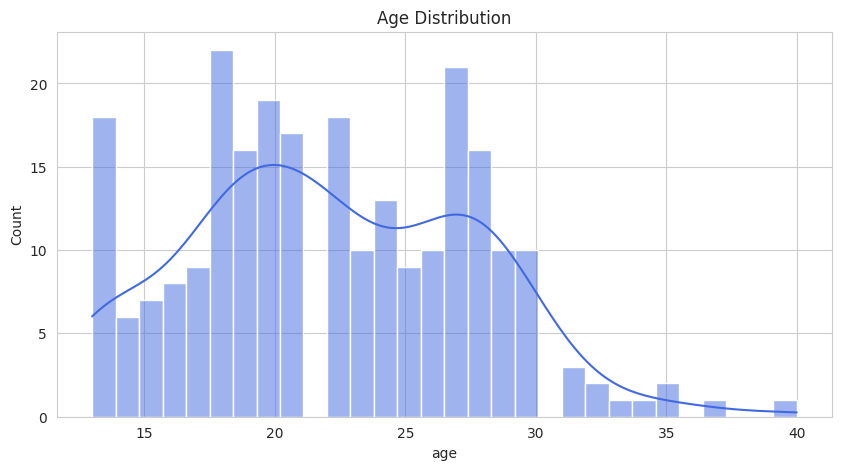

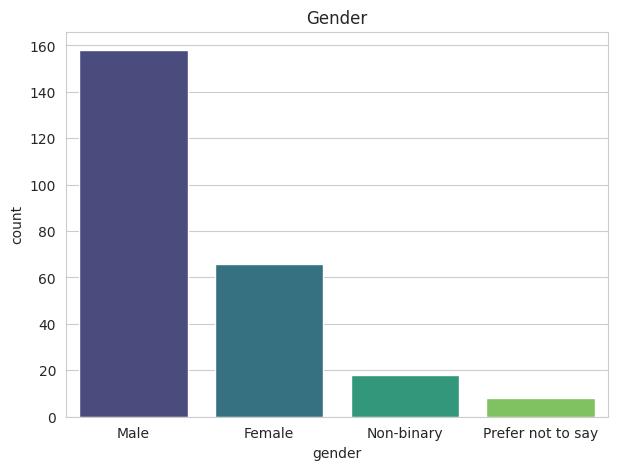

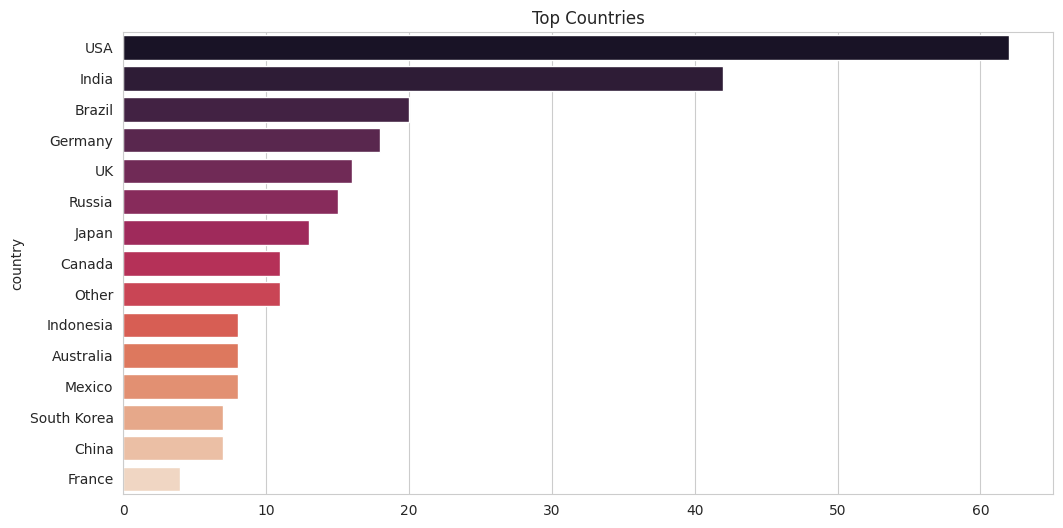

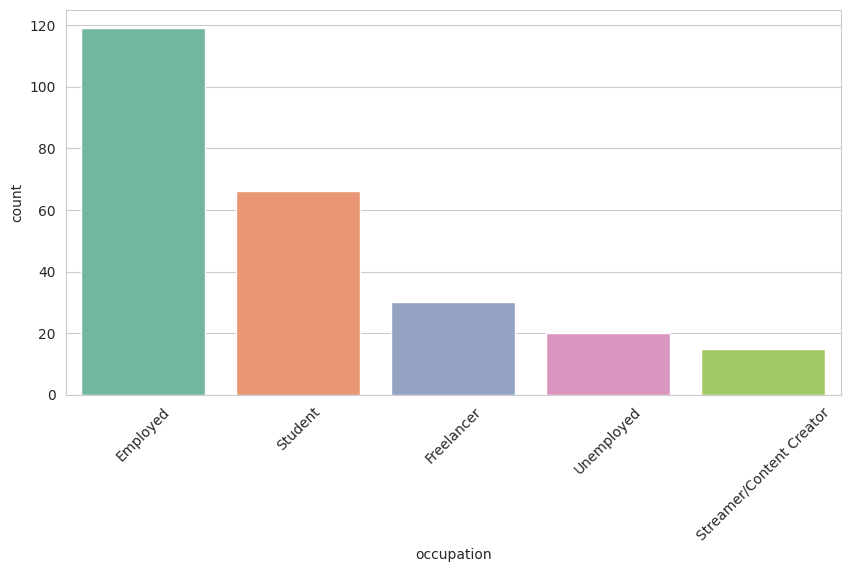

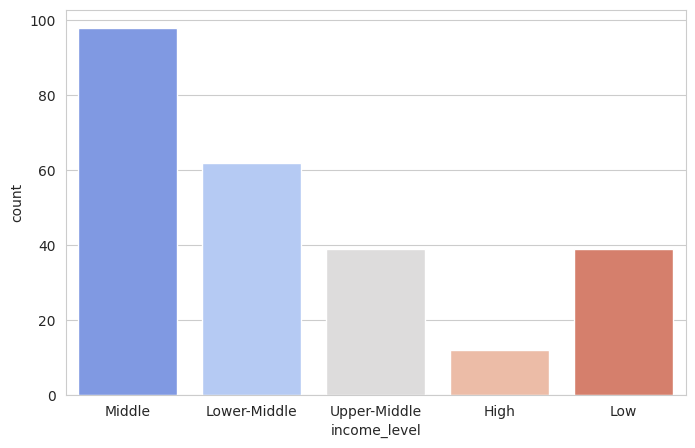

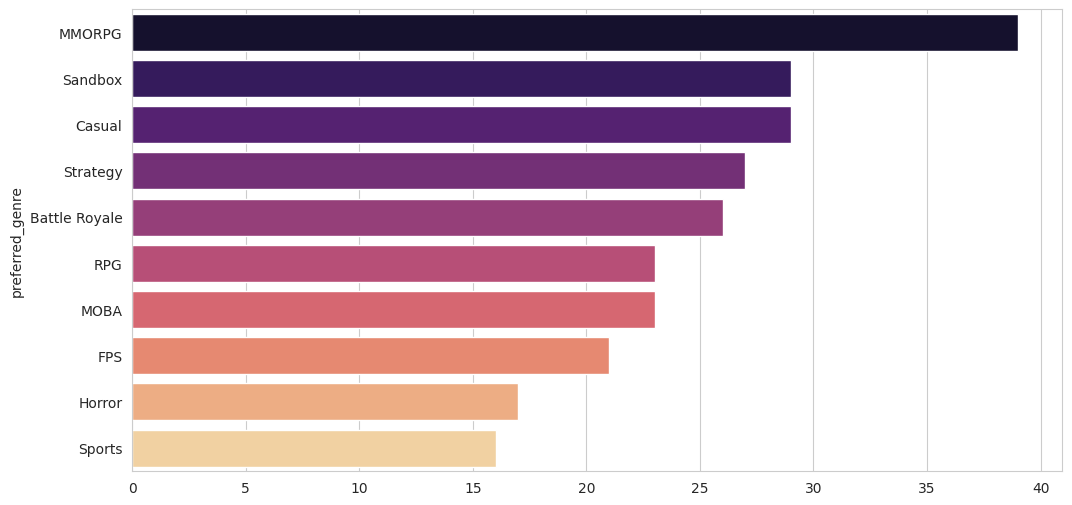

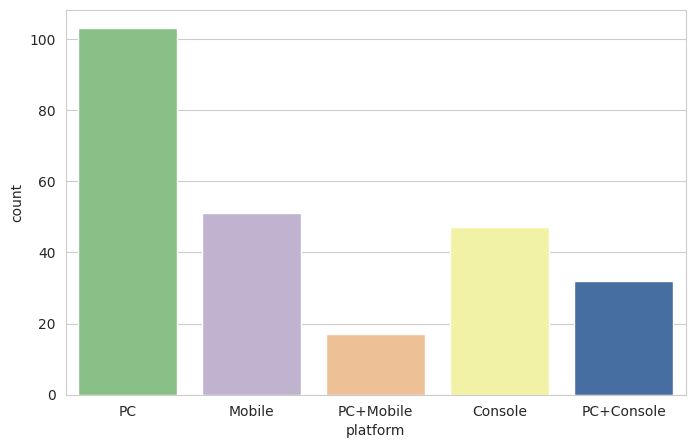

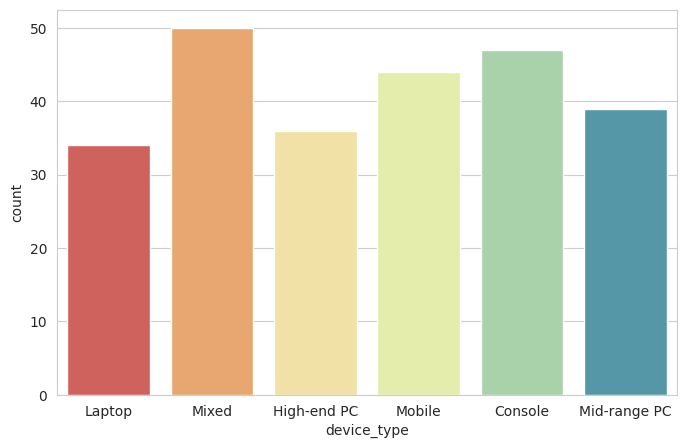

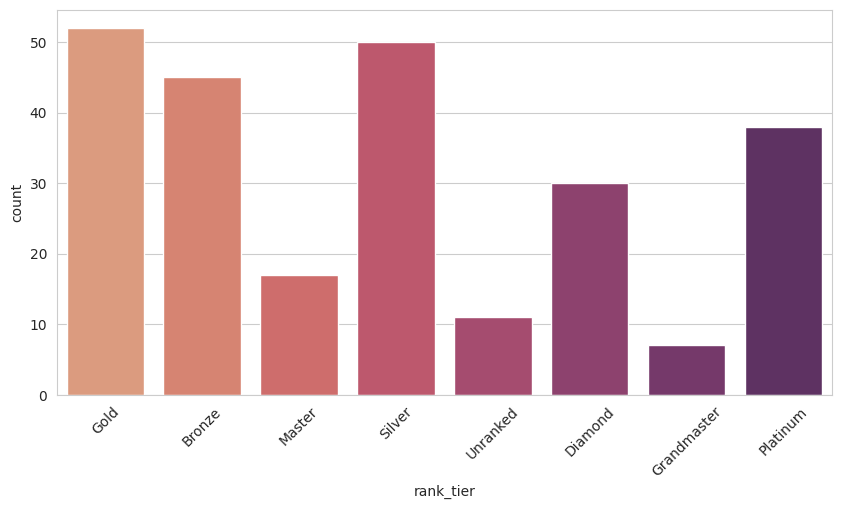

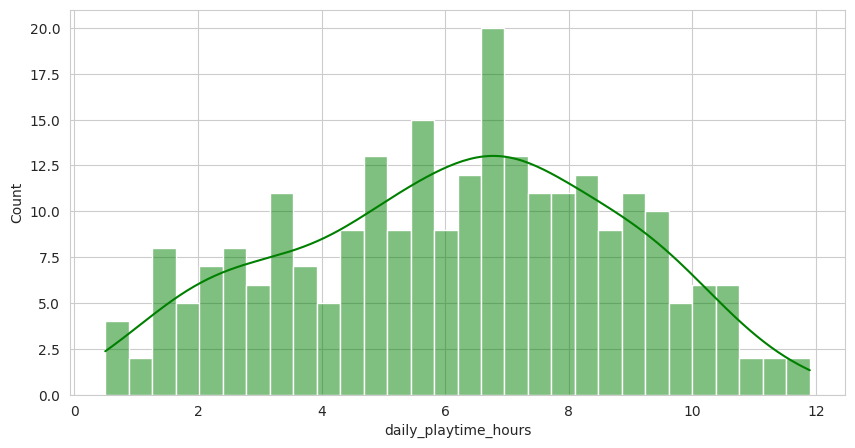

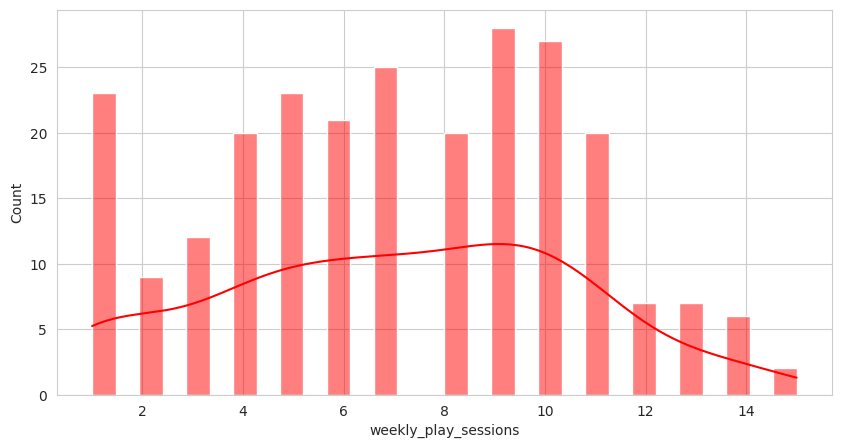

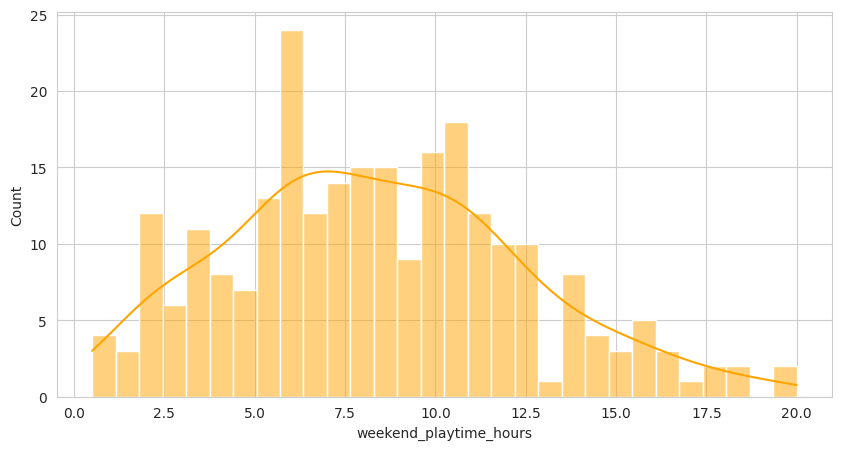

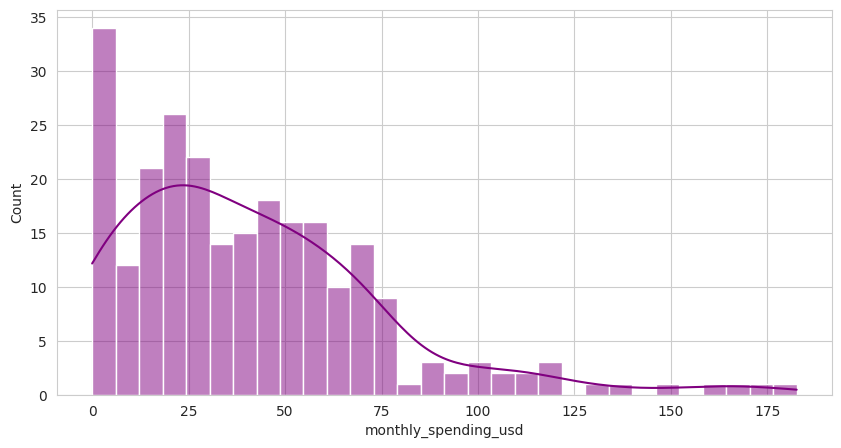

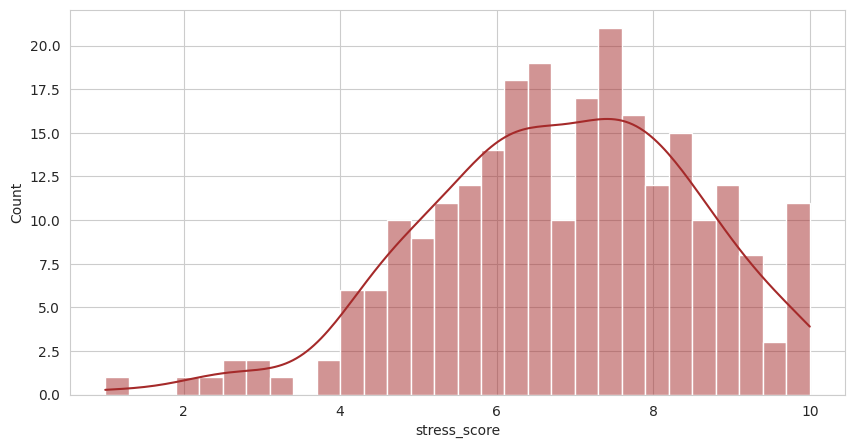

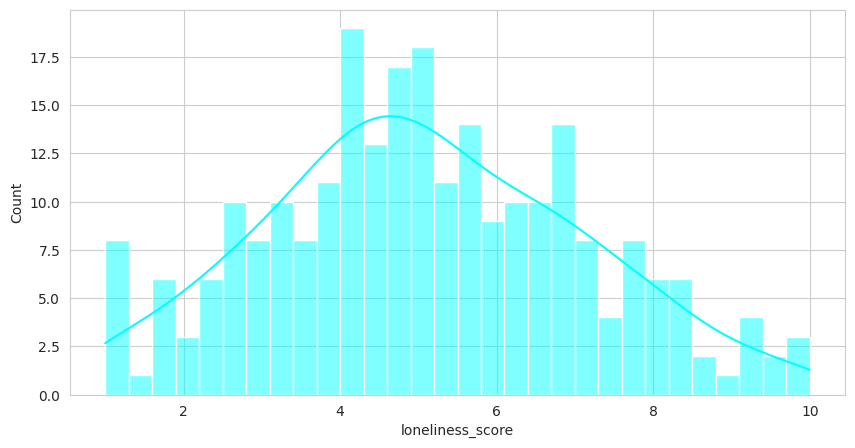

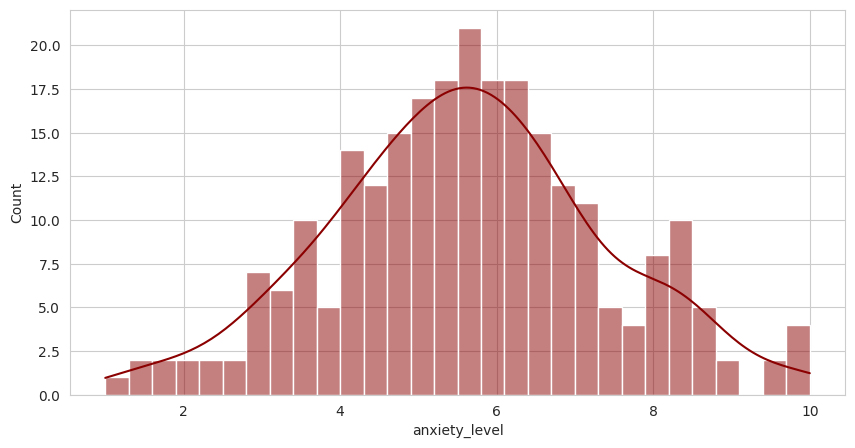

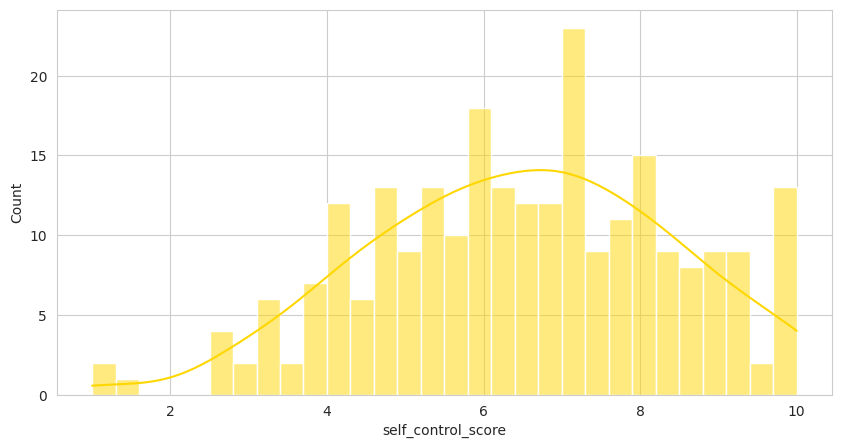

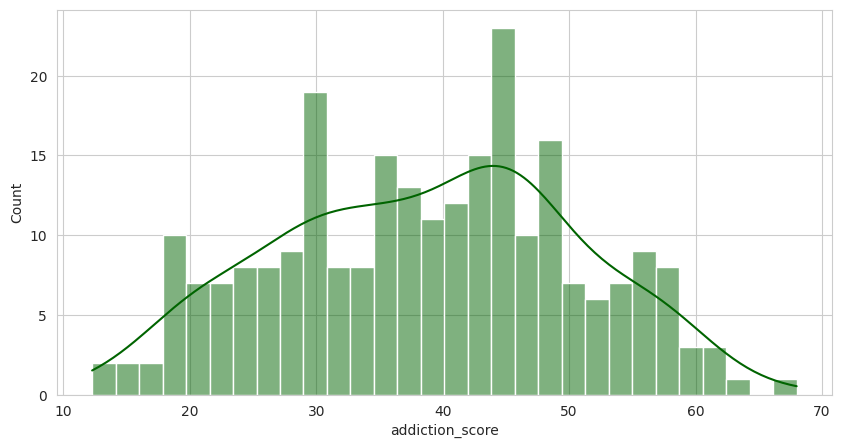

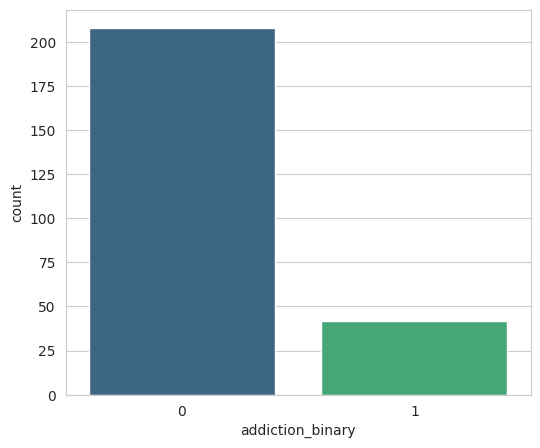

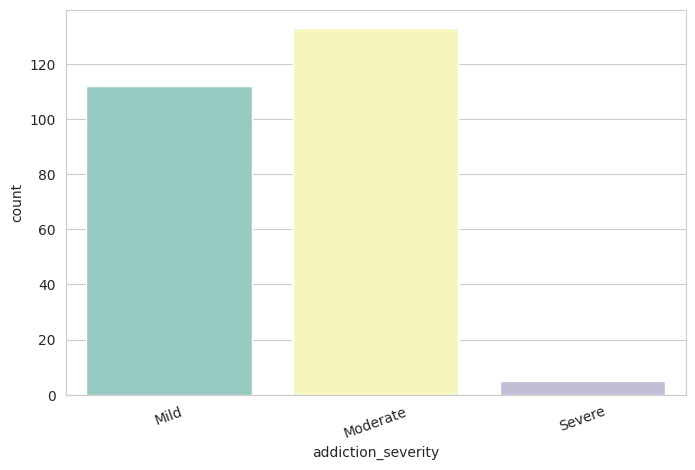

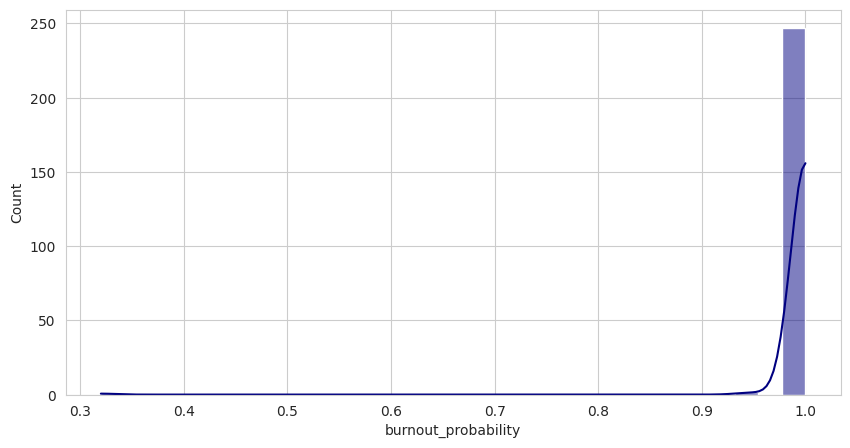

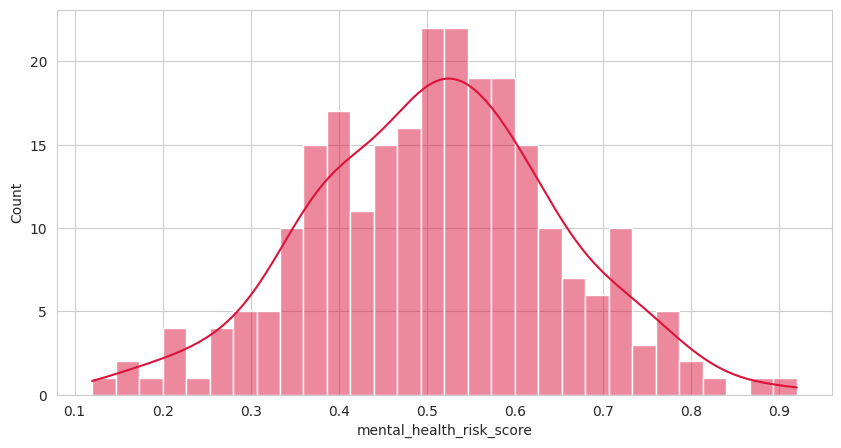

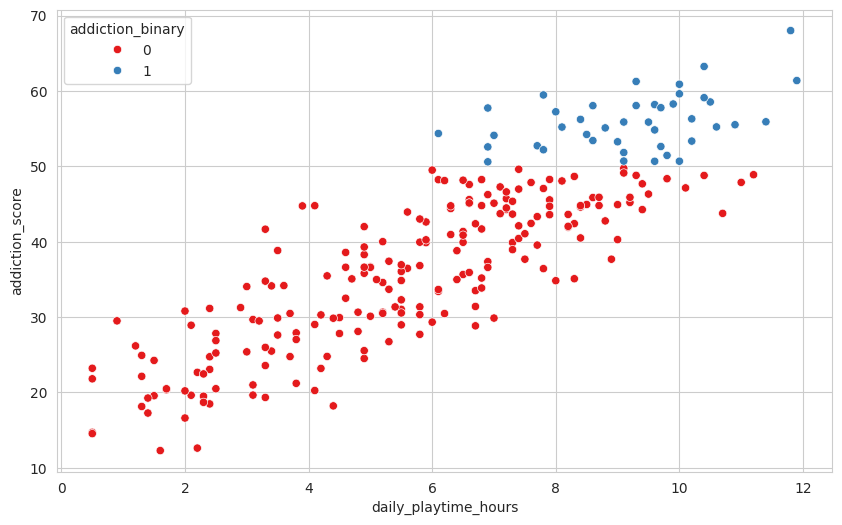

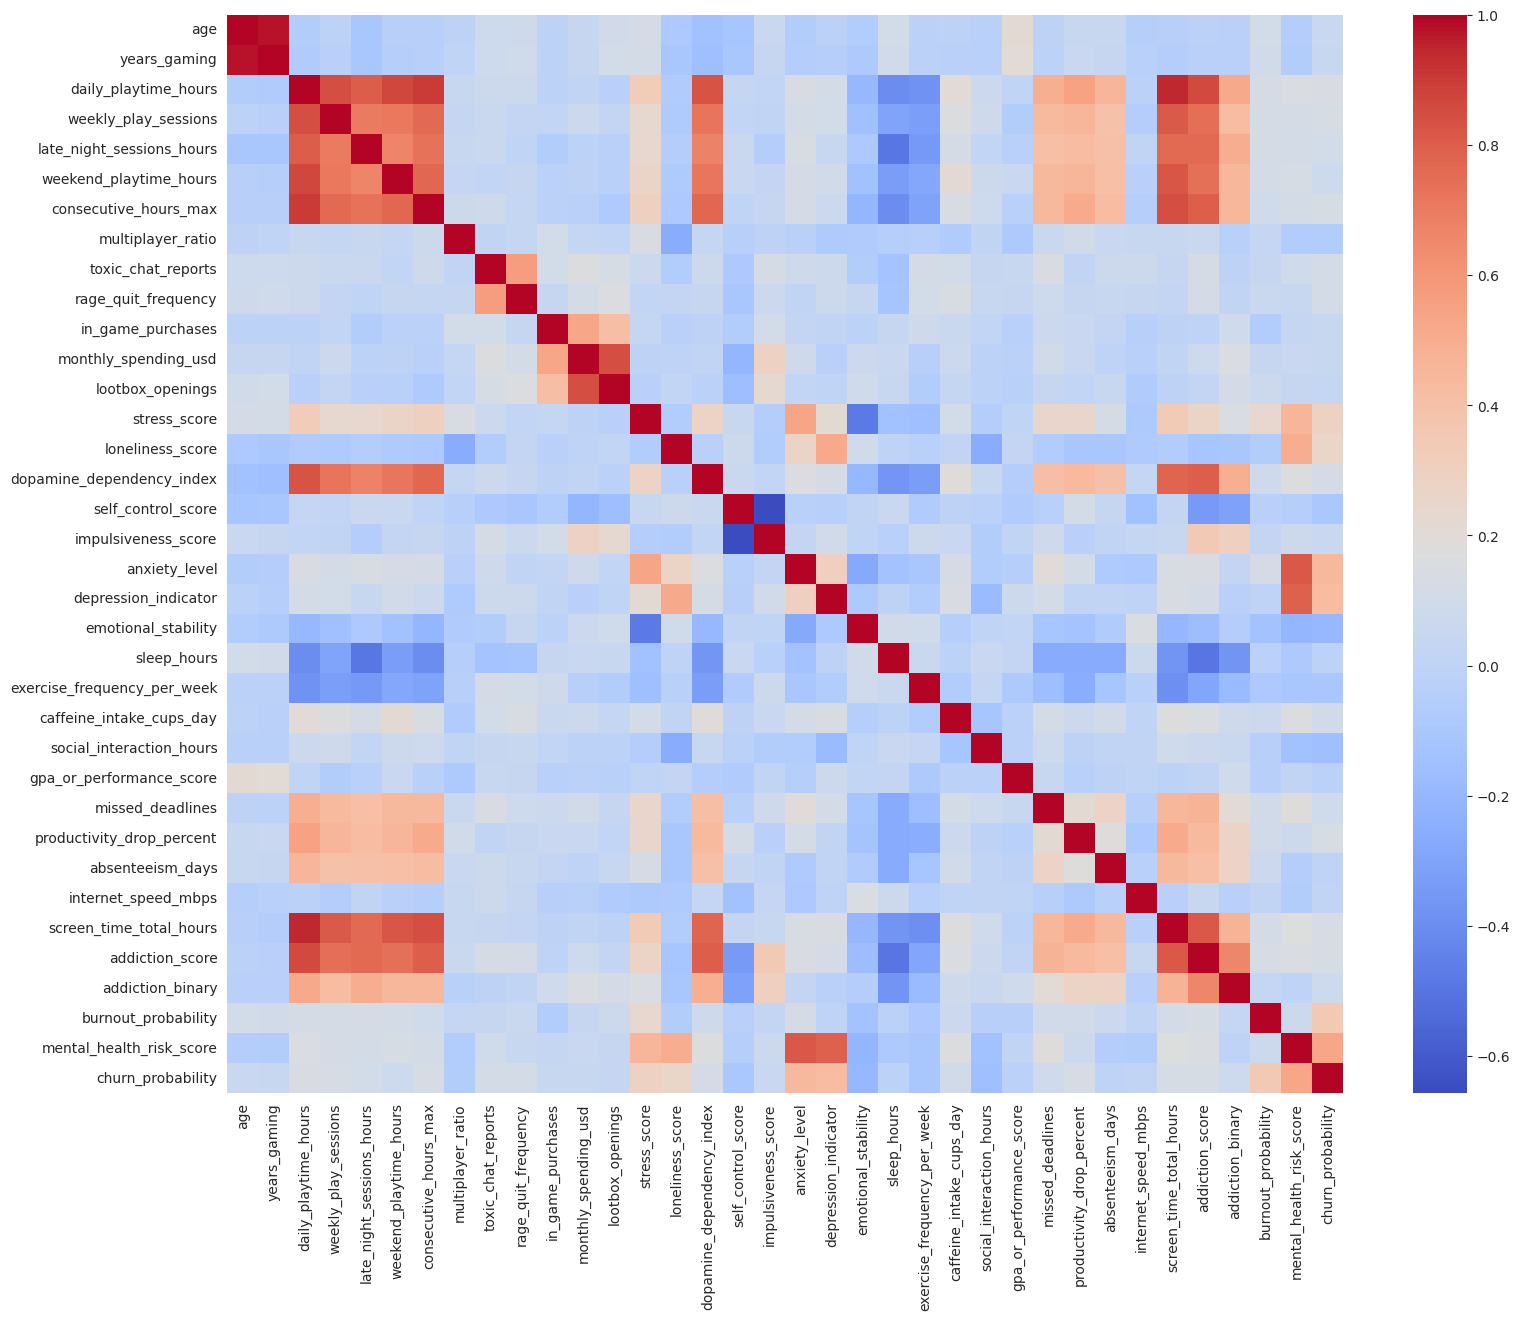

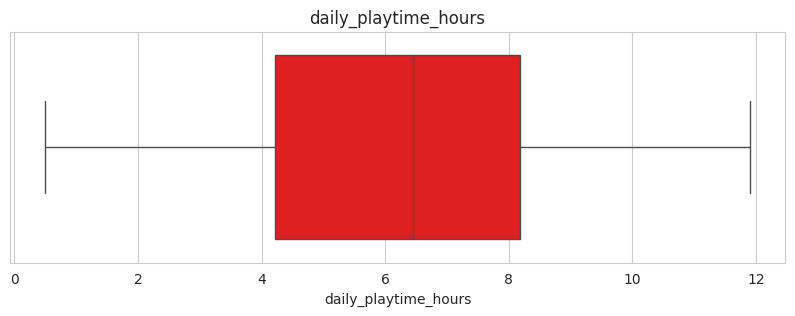

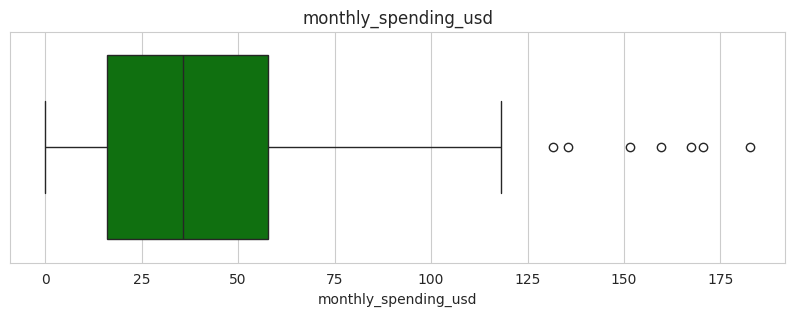

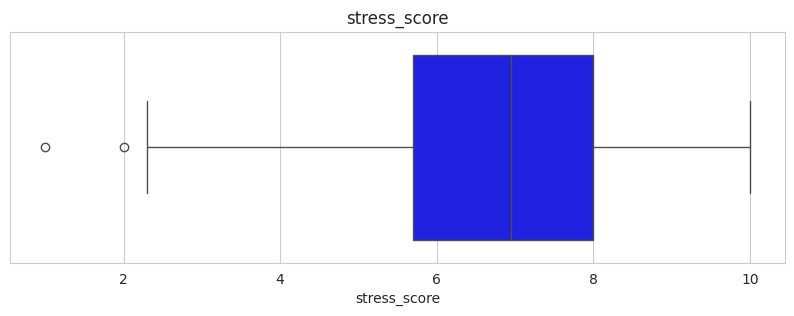

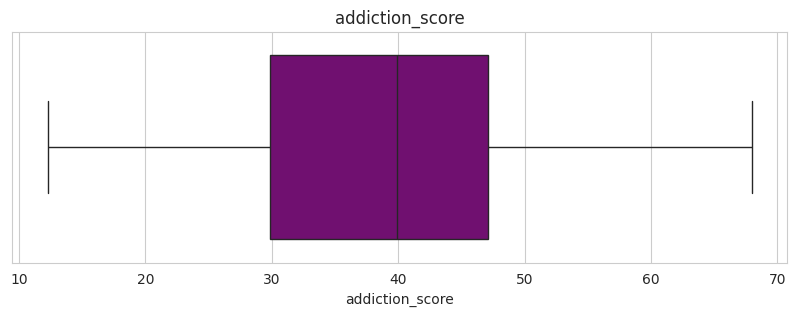

Visualization Completed Successfully


In [12]:
# ============================================================
# 1 AGE
# ============================================================

plt.figure(figsize=(10,5))
sns.histplot(df["age"], bins=30, kde=True, color="royalblue")
plt.title("Age Distribution")
plt.show()

# ============================================================
# 2 GENDER
# ============================================================

plt.figure(figsize=(7,5))
sns.countplot(data=df,x="gender",hue="gender",
              palette="viridis",legend=False)
plt.title("Gender")
plt.show()

# ============================================================
# 3 COUNTRY
# ============================================================

plt.figure(figsize=(12,6))

country=df["country"].value_counts().head(15)

sns.barplot(x=country.values,
            y=country.index,
            hue=country.index,
            palette="rocket",
            legend=False)

plt.title("Top Countries")
plt.show()

# ============================================================
# 4 OCCUPATION
# ============================================================

plt.figure(figsize=(10,5))

sns.countplot(data=df,
              x="occupation",
              hue="occupation",
              palette="Set2",
              legend=False)

plt.xticks(rotation=45)

plt.show()

# ============================================================
# 5 INCOME LEVEL
# ============================================================

plt.figure(figsize=(8,5))

sns.countplot(data=df,
              x="income_level",
              hue="income_level",
              palette="coolwarm",
              legend=False)

plt.show()

# ============================================================
# 6 GENRE
# ============================================================

plt.figure(figsize=(12,6))

genre=df["preferred_genre"].value_counts()

sns.barplot(x=genre.values,
            y=genre.index,
            hue=genre.index,
            palette="magma",
            legend=False)

plt.show()

# ============================================================
# 7 PLATFORM
# ============================================================

plt.figure(figsize=(8,5))

sns.countplot(data=df,
              x="platform",
              hue="platform",
              palette="Accent",
              legend=False)

plt.show()

# ============================================================
# 8 DEVICE
# ============================================================

plt.figure(figsize=(8,5))

sns.countplot(data=df,
              x="device_type",
              hue="device_type",
              palette="Spectral",
              legend=False)

plt.show()

# ============================================================
# 9 RANK
# ============================================================

plt.figure(figsize=(10,5))

sns.countplot(data=df,
              x="rank_tier",
              hue="rank_tier",
              palette="flare",
              legend=False)

plt.xticks(rotation=45)

plt.show()

# ============================================================
# 10 PLAYTIME
# ============================================================

plt.figure(figsize=(10,5))

sns.histplot(df["daily_playtime_hours"],
             bins=30,
             kde=True,
             color="green")

plt.show()

# ============================================================
# 11 WEEKLY SESSIONS
# ============================================================

plt.figure(figsize=(10,5))

sns.histplot(df["weekly_play_sessions"],
             bins=30,
             kde=True,
             color="red")

plt.show()

# ============================================================
# 12 WEEKEND PLAYTIME
# ============================================================

plt.figure(figsize=(10,5))

sns.histplot(df["weekend_playtime_hours"],
             bins=30,
             kde=True,
             color="orange")

plt.show()

# ============================================================
# 13 MONTHLY SPENDING
# ============================================================

plt.figure(figsize=(10,5))

sns.histplot(df["monthly_spending_usd"],
             bins=30,
             kde=True,
             color="purple")

plt.show()

# ============================================================
# 14 STRESS
# ============================================================

plt.figure(figsize=(10,5))

sns.histplot(df["stress_score"],
             bins=30,
             kde=True,
             color="brown")

plt.show()

# ============================================================
# 15 LONELINESS
# ============================================================

plt.figure(figsize=(10,5))

sns.histplot(df["loneliness_score"],
             bins=30,
             kde=True,
             color="cyan")

plt.show()

# ============================================================
# 16 ANXIETY
# ============================================================

plt.figure(figsize=(10,5))

sns.histplot(df["anxiety_level"],
             bins=30,
             kde=True,
             color="darkred")

plt.show()

# ============================================================
# 17 SELF CONTROL
# ============================================================

plt.figure(figsize=(10,5))

sns.histplot(df["self_control_score"],
             bins=30,
             kde=True,
             color="gold")

plt.show()

# ============================================================
# 18 ADDICTION SCORE
# ============================================================

plt.figure(figsize=(10,5))

sns.histplot(df["addiction_score"],
             bins=30,
             kde=True,
             color="darkgreen")

plt.show()

# ============================================================
# 19 ADDICTION BINARY
# ============================================================

plt.figure(figsize=(6,5))

sns.countplot(data=df,
              x="addiction_binary",
              hue="addiction_binary",
              palette="viridis",
              legend=False)

plt.show()

# ============================================================
# 20 ADDICTION SEVERITY
# ============================================================

plt.figure(figsize=(8,5))

sns.countplot(data=df,
              x="addiction_severity",
              hue="addiction_severity",
              palette="Set3",
              legend=False)

plt.xticks(rotation=20)

plt.show()

# ============================================================
# 21 BURNOUT
# ============================================================

plt.figure(figsize=(10,5))

sns.histplot(df["burnout_probability"],
             bins=30,
             kde=True,
             color="navy")

plt.show()

# ============================================================
# 22 MENTAL HEALTH RISK
# ============================================================

plt.figure(figsize=(10,5))

sns.histplot(df["mental_health_risk_score"],
             bins=30,
             kde=True,
             color="crimson")

plt.show()

# ============================================================
# 23 PLAYTIME VS ADDICTION
# ============================================================

plt.figure(figsize=(10,6))

sns.scatterplot(data=df,
                x="daily_playtime_hours",
                y="addiction_score",
                hue="addiction_binary",
                palette="Set1")

plt.show()

# ============================================================
# 24 CORRELATION
# ============================================================

plt.figure(figsize=(18,14))

numeric=df.select_dtypes(include=np.number)

sns.heatmap(numeric.corr(),
            cmap="coolwarm")

plt.show()

# ============================================================
# 25 OUTLIERS
# ============================================================

cols=[
"daily_playtime_hours",
"monthly_spending_usd",
"stress_score",
"addiction_score"
]

colors=[
"red",
"green",
"blue",
"purple"
]

for c,col in zip(colors,cols):

    plt.figure(figsize=(10,3))

    sns.boxplot(x=df[col],color=c)

    plt.title(col)

    plt.show()

print("Visualization Completed Successfully")

## Features Engineering

Logistic Regression
Accuracy : 0.92
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        42
           1       0.75      0.75      0.75         8

    accuracy                           0.92        50
   macro avg       0.85      0.85      0.85        50
weighted avg       0.92      0.92      0.92        50

Decision Tree
Accuracy : 0.82
              precision    recall  f1-score   support

           0       0.88      0.90      0.89        42
           1       0.43      0.38      0.40         8

    accuracy                           0.82        50
   macro avg       0.66      0.64      0.65        50
weighted avg       0.81      0.82      0.82        50

Random Forest
Accuracy : 0.88
              precision    recall  f1-score   support

           0       0.89      0.98      0.93        42
           1       0.75      0.38      0.50         8

    accuracy                           0.88        50
   macro avg       0.82      0.6

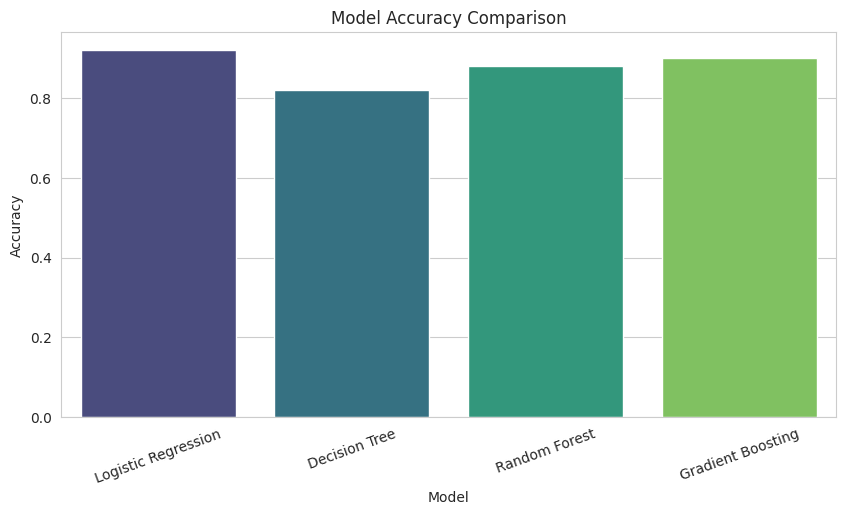

Best Model : Logistic Regression


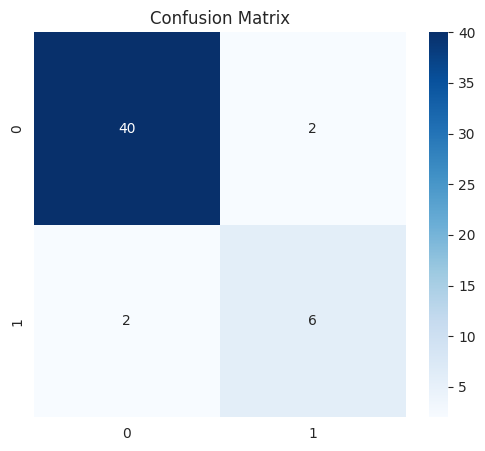

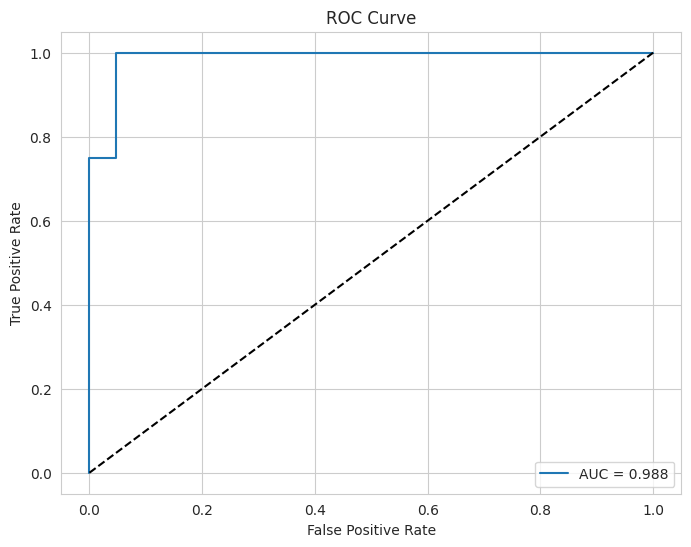

ROC AUC : 0.9881


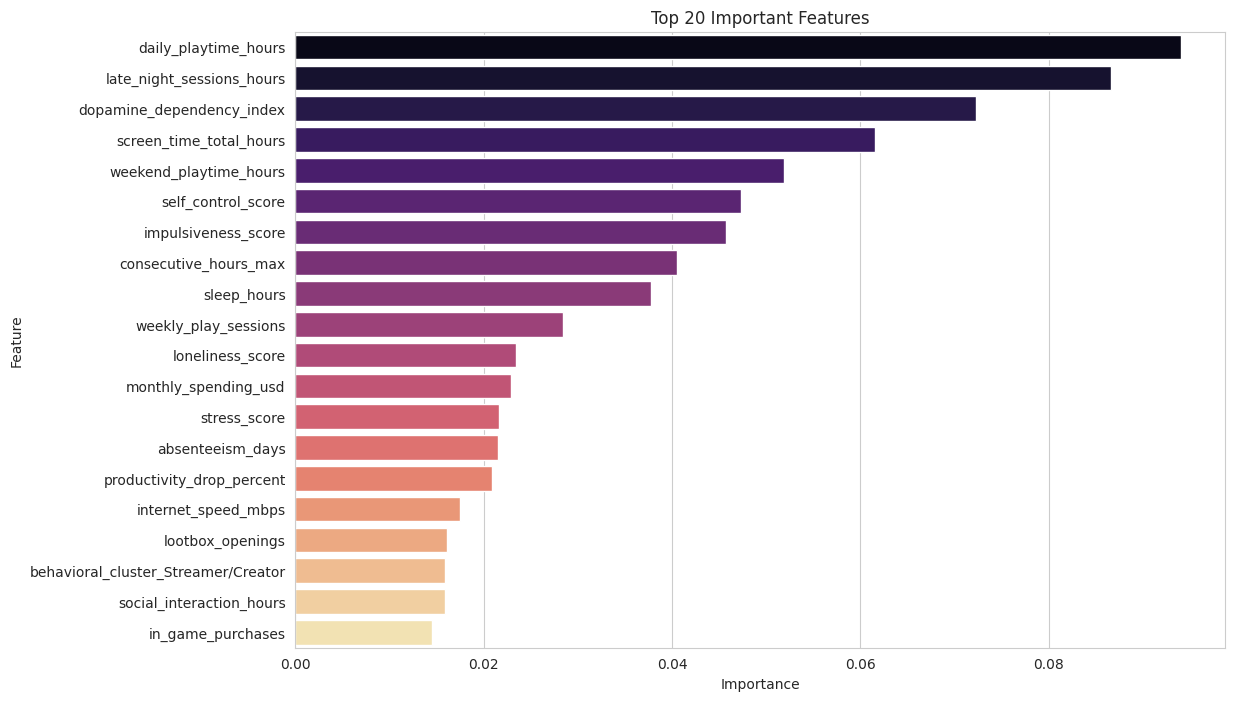


FINAL RESULTS
Logistic Regression: 0.9200
Decision Tree: 0.8200
Random Forest: 0.8800
Gradient Boosting: 0.9000
Best Model : Logistic Regression
Best Accuracy : 0.92


In [13]:
from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")


# ============================================================
# TARGET
# ============================================================

target = "addiction_binary"

X = df.drop(columns=[target])

y = df[target]

# ============================================================
# REMOVE DATA LEAKAGE
# ============================================================

drop_cols = [
    "user_id",
    "addiction_score",
    "addiction_severity",
    "mental_health_risk_score",
    "burnout_probability"
]

X = X.drop(columns=drop_cols, errors="ignore")

# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ============================================================
# COLUMN TYPES
# ============================================================

numeric_cols = X_train.select_dtypes(include=np.number).columns

categorical_cols = X_train.select_dtypes(include="object").columns

# ============================================================
# PREPROCESSING
# ============================================================

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

# ============================================================
# MODELS
# ============================================================

models = {
    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(random_state=42)
}

results = {}
trained_models = {}

# ============================================================
# TRAINING
# ============================================================

for name, model in models.items():

    print("="*60)
    print(name)
    print("="*60)

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    prediction = pipe.predict(X_test)

    accuracy = accuracy_score(y_test, prediction)

    results[name] = accuracy

    trained_models[name] = pipe

    print("Accuracy :", round(accuracy,4))
    print(classification_report(y_test, prediction))

# ============================================================
# ACCURACY COMPARISON
# ============================================================

accuracy_df = pd.DataFrame({
    "Model": list(results.keys()),
    "Accuracy": list(results.values())
})

plt.figure(figsize=(10,5))

sns.barplot(
    data=accuracy_df,
    x="Model",
    y="Accuracy",
    hue="Model",
    palette="viridis",
    legend=False
)

plt.title("Model Accuracy Comparison")
plt.xticks(rotation=20)
plt.show()

# ============================================================
# BEST MODEL
# ============================================================

best_name = max(results, key=results.get)

best_model = trained_models[best_name]

print("Best Model :", best_name)

# ============================================================
# CONFUSION MATRIX
# ============================================================

prediction = best_model.predict(X_test)

plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, prediction),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

# ============================================================
# ROC CURVE
# ============================================================

probability = best_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, probability)

auc = roc_auc_score(y_test, probability)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

print("ROC AUC :", round(auc,4))

# ============================================================
# FEATURE IMPORTANCE
# ============================================================

rf = trained_models["Random Forest"]

feature_names = (
    list(numeric_cols)
    +
    list(
        rf.named_steps["preprocessor"]
          .named_transformers_["cat"]
          .named_steps["encoder"]
          .get_feature_names_out(categorical_cols)
    )
)

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.named_steps["model"].feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

plt.figure(figsize=(12,8))

sns.barplot(
    data=importance.head(20),
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="magma",
    legend=False
)

plt.title("Top 20 Important Features")
plt.show()

# ============================================================
# FINAL RESULTS
# ============================================================

print("\nFINAL RESULTS")
print("="*50)

for model, score in results.items():
    print(f"{model}: {score:.4f}")

print("="*50)
print("Best Model :", best_name)
print("Best Accuracy :", round(max(results.values()),4))

## Thanks............Please Upvote